In [1]:
import numpy as np
from PIL import Image 

In [2]:
def load_image_as_dataset(path):
    
    # Load image

    img = Image.open(path).convert("RGB")
    img = np.array(img, dtype=np.float32) 
    
    H, W, _ = img.shape
    N = H * W


    # Build color matrix C_raw (N,3)
    
    C_raw = img.reshape(-1, 3)  


    # Build spatial matrix S_raw 
    
    rows = np.repeat(np.arange(H), W)
    cols = np.tile(np.arange(W), H)
    S_raw = np.stack([rows, cols], axis=1).astype(np.float32) 

    
    # Normalization
    
    S_norm = S_raw / np.array([[H, W]], dtype=np.float32)   
    C_norm = C_raw / 255.0                                  

    

    print("Image loaded:", path)
    print("Raw color shape:", C_raw.shape)
    print("Raw spatial shape:", S_raw.shape)
    print("Normalized color range:", float(C_norm.min()), "to", float(C_norm.max()))
    print("Normalized spatial range:", float(S_norm.min()), "to", float(S_norm.max()))

    return S_raw, C_raw, S_norm, C_norm, img

In [3]:
S1_raw, C1_raw, S1_norm, C1_norm, img1 = load_image_as_dataset("image1.png")

S2_raw, C2_raw, S2_norm, C2_norm, img2 = load_image_as_dataset("image2.png")

Image loaded: image1.png
Raw color shape: (10000, 3)
Raw spatial shape: (10000, 2)
Normalized color range: 0.0 to 1.0
Normalized spatial range: 0.0 to 0.9900000095367432
Image loaded: image2.png
Raw color shape: (10000, 3)
Raw spatial shape: (10000, 2)
Normalized color range: 0.0 to 1.0
Normalized spatial range: 0.0 to 0.9900000095367432


In [4]:
def compute_kernel_matrix(S_norm, C_norm, gamma_s=50.0, gamma_c=5.0):
    
    N = S_norm.shape[0]

    
    K = np.zeros((N, N), dtype=np.float32)

    # Compute squared norms 
    S_sq = np.sum(S_norm ** 2, axis=1, keepdims=True)   
    C_sq = np.sum(C_norm ** 2, axis=1, keepdims=True)   

    
    spatial_d2 = S_sq + S_sq.T - 2 * (S_norm @ S_norm.T)


    color_d2 = C_sq + C_sq.T - 2 * (C_norm @ C_norm.T)

    # kernel
    K = np.exp(-gamma_s * spatial_d2) * np.exp(-gamma_c * color_d2)

    return K

In [5]:
K1 = compute_kernel_matrix(S1_norm, C1_norm, gamma_s=50.0, gamma_c=5.0)


K2 = compute_kernel_matrix(S2_norm, C2_norm, gamma_s=50.0, gamma_c=5.0)


In [6]:
print(K1.shape)
print(K2.shape)

(10000, 10000)
(10000, 10000)


In [7]:
def kernel_kmeans(K, H=100, W=100, k=2, max_iter=20, save_prefix="kkm"):
    N = K.shape[0]

    
    #  Random initialization
    
    labels = np.random.randint(0, k, size=N)

    for iteration in range(max_iter):
        print(f"Iteration {iteration}")

        #  Compute cluster members
        
        clusters = [np.where(labels == c)[0] for c in range(k)]
        sizes = np.array([len(c) for c in clusters])

        
        for c in range(k):
            if sizes[c] == 0:
                
                rand_idx = np.random.randint(N)
                labels[rand_idx] = c
                clusters[c] = np.array([rand_idx])
                sizes[c] = 1

        # Precompute KK[c]
        
        KK = np.zeros(k)
        for c in range(k):
            idx = clusters[c]
            KK[c] = np.sum(K[np.ix_(idx, idx)])

        # Compute distances for all clusters
        
        distances = np.zeros((N, k), dtype=np.float64)

        K_diag = np.diag(K)

        for c in range(k):
            idx = clusters[c]
            size_c = sizes[c]

            sum_K_i_c = np.sum(K[:, idx], axis=1)

            distances[:, c] = (
                K_diag
                - (2.0 / size_c) * sum_K_i_c
                + (1.0 / (size_c * size_c)) * KK[c]
            )

        # Update labels

        new_labels = np.argmin(distances, axis=1)

        # Checking convergence
        if np.all(new_labels == labels):
            print("Converged")
            break

        labels = new_labels

        # Save segmentation image
        seg = labels.reshape(H, W)

        # Map clusters to grayscale
        seg_img = (seg * (255 // (k - 1))).astype(np.uint8)

        Image.fromarray(seg_img).save(f"{save_prefix}_{iteration}.png")

    return labels


In [7]:


def create_gif_pil(prefix, num_frames, output="kkm.gif", duration=300):
    frames = []
    for i in range(num_frames):
        img = Image.open(f"{prefix}_{i}.png")
        frames.append(img)

    frames[0].save(
        output,
        save_all=True,
        append_images=frames[1:],
        duration=duration,   # duration in milliseconds
        loop=0
    )

    print(f"GIF saved as {output}")


In [12]:
labels1 = kernel_kmeans(K1, H=100, W=100, k=2, save_prefix="img1_kkm")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [13]:
create_gif_pil("img1_kkm", num_frames=10, output="img1_kernel_kmeans.gif")


GIF saved as img1_kernel_kmeans.gif


In [14]:
labels2 = kernel_kmeans(K2, H=100, W=100, k=2, save_prefix="img2_kkm")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [16]:
create_gif_pil("img2_kkm", num_frames=20, output="img2_kernel_kmeans.gif")


GIF saved as img2_kernel_kmeans.gif


In [9]:


def kmeans_euclidean(X, H=100, W=100, k_clusters=2, max_iter=20, save_prefix="spec"):
    
    N, d = X.shape

    # Randomly initialize centroids from data points
    rng = np.random.default_rng()
    init_indices = rng.choice(N, size=k_clusters, replace=False)
    centroids = X[init_indices].copy()


    labels = np.zeros(N, dtype=np.int32)

    for it in range(max_iter):
        print(f"k-means iteration {it}")

    
        distances = np.zeros((N, k_clusters), dtype=np.float64)
        for c in range(k_clusters):
            diff = X - centroids[c]        # shape (N, d)
            distances[:, c] = np.sum(diff * diff, axis=1)

        new_labels = np.argmin(distances, axis=1)

        
        seg = new_labels.reshape(H, W)

        if k_clusters > 1:
            seg_img = (seg * (255 // (k_clusters - 1))).astype(np.uint8)
        else:
            seg_img = (seg * 255).astype(np.uint8)

        Image.fromarray(seg_img).save(f"{save_prefix}_{it}.png")

        # check convergence
        if it > 0 and np.all(new_labels == labels):
            print("k-means converged!")
            labels = new_labels
            break

    
        labels = new_labels

    
        for c in range(k_clusters):
            idx = np.where(labels == c)[0]
            if len(idx) == 0:
                
                rand_idx = rng.integers(0, N)
                centroids[c] = X[rand_idx]
            else:
                centroids[c] = X[idx].mean(axis=0)

    return labels


In [8]:
def spectral_ratio_cut(K, H=100, W=100, k_clusters=2, max_iter_kmeans=20, save_prefix="spec_ratio"):
    
    N = K.shape[0]

    # Degree vector
    d = np.sum(K, axis=1)

    # Unnormalized Laplacian L = D - W
    L = np.diag(d) - K

    
    eigvals, eigvecs = np.linalg.eigh(L)

    # Take k smallest eigenvectors
    U = eigvecs[:, :k_clusters] 

    
    labels = kmeans_euclidean(U, H=H, W=W, k_clusters=k_clusters,max_iter=max_iter_kmeans, save_prefix=save_prefix)

    return labels, U


In [9]:
def spectral_normalized_cut(K, H=100, W=100, k_clusters=2, max_iter_kmeans=20, save_prefix="spec_ncut"):
    
    N = K.shape[0]

    # Degree vector
    d = np.sum(K, axis=1)

    # Handle zero degrees
    eps = 1e-12
    d_inv_sqrt = 1.0 / np.sqrt(d + eps)
    d_inv_sqrt[d <= eps] = 0.0

    # Compute A = D^{-1/2} K D^{-1/2}
    A = d_inv_sqrt[:, None] * K * d_inv_sqrt[None, :]

    # L_sym = I - A
    L_sym = np.eye(N) - A

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(L_sym)

    # Take k smallest eigenvectors
    U = eigvecs[:, :k_clusters]

    # Row-normalize U
    norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normed = U / (norms + 1e-12)


    labels = kmeans_euclidean(U_normed, H=H, W=W, k_clusters=k_clusters,max_iter=max_iter_kmeans, save_prefix=save_prefix)

    return labels, U_normed


In [12]:
labels1_ratio, U1_ratio = spectral_ratio_cut(
    K1, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img1_spec_ratio"
)


k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means converged!


In [13]:
create_gif_pil("img1_spec_ratio", num_frames=3, output="img1_spectral_ratio.gif")


GIF saved as img1_spectral_ratio.gif


In [14]:

labels1_ncut, U1_ncut = spectral_normalized_cut(
    K1, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img1_spec_ncut"
)





k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means converged!


In [15]:
create_gif_pil("img1_spec_ncut", num_frames=6, output="img1_spectral_ncut.gif")


GIF saved as img1_spectral_ncut.gif


In [16]:
labels2_ratio, U2_ratio = spectral_ratio_cut(
    K2, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img2_spec_ratio"
)






k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means iteration 12
k-means converged!


In [ ]:
create_gif_pil("img2_spec_ratio", num_frames=13, output="img1_spectral_ratio.gif")




labels2_ncut, U2_ncut = spectral_normalized_cut(
    K2, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img2_spec_ncut"
)







GIF saved as img1_spectral_ratio.gif
k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means converged!
GIF saved as img2_spectral_ncut.gif


In [18]:
create_gif_pil("img2_spec_ncut", num_frames=8, output="img2_spectral_ncut.gif")


GIF saved as img2_spectral_ncut.gif


In [19]:
labels1_k3 = kernel_kmeans(K1, H=100, W=100, k=3, save_prefix="img1_kkm_k3")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [20]:
create_gif_pil("img1_kkm_k3", num_frames=20, output="img1_kernel_kmeans_k3.gif")


GIF saved as img1_kernel_kmeans_k3.gif


In [21]:
labels1_k4 = kernel_kmeans(K1, H=100, W=100, k=4, save_prefix="img1_kkm_k4")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [22]:
create_gif_pil("img1_kkm_k4", num_frames=20, output="img1_kernel_kmeans_k4.gif")


GIF saved as img1_kernel_kmeans_k4.gif


In [25]:
labels2_k3 = kernel_kmeans(K2, H=100, W=100, k=3, save_prefix="img2_kkm_k3")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [27]:
create_gif_pil("img2_kkm_k3", num_frames=20, output="img2_kernel_kmeans_k3.gif")


GIF saved as img2_kernel_kmeans_k3.gif


In [29]:
labels2_k4 = kernel_kmeans(K2, H=100, W=100, k=4, save_prefix="img2_kkm_k4")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19


In [30]:
create_gif_pil("img2_kkm_k4", num_frames=20, output="img2_kernel_kmeans_k4.gif")


GIF saved as img2_kernel_kmeans_k4.gif


In [31]:
labels1_ratio_k3, U1_ratio_k3 = spectral_ratio_cut(
    K1, H=100, W=100, k_clusters=3, save_prefix="img1_spec_ratio_k3"
)



k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means converged!


In [32]:
create_gif_pil("img1_spec_ratio_k3", num_frames=6, output="img1_spectral_ratio_k3.gif")

GIF saved as img1_spectral_ratio_k3.gif


In [33]:
labels1_ratio_k4, U1_ratio_k4 = spectral_ratio_cut(
    K1, H=100, W=100, k_clusters=4, save_prefix="img1_spec_ratio_k4"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means converged!


In [34]:
create_gif_pil("img1_spec_ratio_k4", num_frames=8, output="img1_spectral_ratio_k4.gif")


GIF saved as img1_spectral_ratio_k4.gif


In [35]:
labels2_ratio_k3, U2_ratio_k3 = spectral_ratio_cut(
    K2, H=100, W=100, k_clusters=3, save_prefix="img2_spec_ratio_k3"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means iteration 12
k-means iteration 13
k-means iteration 14
k-means converged!


In [36]:
create_gif_pil("img2_spec_ratio_k3", num_frames=15, output="img2_spectral_ratio_k3.gif")


GIF saved as img2_spectral_ratio_k3.gif


In [37]:
labels2_ratio_k4, U2_ratio_k4 = spectral_ratio_cut(
    K2, H=100, W=100, k_clusters=4, save_prefix="img2_spec_ratio_k4"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means iteration 12
k-means iteration 13
k-means iteration 14
k-means iteration 15
k-means iteration 16
k-means iteration 17
k-means iteration 18
k-means iteration 19
k-means converged!


In [38]:
create_gif_pil("img2_spec_ratio_k4", num_frames=20, output="img2_spectral_ratio_k4.gif")


GIF saved as img2_spectral_ratio_k4.gif


In [39]:
labels1_ncut_k3, U1_ncut_k3 = spectral_normalized_cut(
    K1, H=100, W=100, k_clusters=3, save_prefix="img1_spec_ncut_k3"
)


k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means converged!


In [40]:
create_gif_pil("img1_spec_ncut_k3", num_frames=12, output="img1_spectral_ncut_k3.gif")

GIF saved as img1_spectral_ncut_k3.gif


In [41]:
labels1_ncut_k4, U1_ncut_k4 = spectral_normalized_cut(
    K1, H=100, W=100, k_clusters=4, save_prefix="img1_spec_ncut_k4"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means converged!


In [42]:
create_gif_pil("img1_spec_ncut_k4", num_frames=10, output="img1_spectral_ncut_k4.gif")


GIF saved as img1_spectral_ncut_k4.gif


In [43]:
labels2_ncut_k3, U2_ncut_k3 = spectral_normalized_cut(
    K2, H=100, W=100, k_clusters=3, save_prefix="img2_spec_ncut_k3"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means iteration 12
k-means iteration 13
k-means iteration 14
k-means iteration 15
k-means iteration 16
k-means iteration 17
k-means iteration 18
k-means iteration 19


In [45]:
create_gif_pil("img2_spec_ncut_k3", num_frames=20, output="img2_spectral_ncut_k3.gif")


GIF saved as img2_spectral_ncut_k3.gif


In [46]:
labels2_ncut_k4, U2_ncut_k4 = spectral_normalized_cut(
    K2, H=100, W=100, k_clusters=4, save_prefix="img2_spec_ncut_k4"
)

k-means iteration 0
k-means iteration 1
k-means iteration 2
k-means iteration 3
k-means iteration 4
k-means iteration 5
k-means iteration 6
k-means iteration 7
k-means iteration 8
k-means iteration 9
k-means iteration 10
k-means iteration 11
k-means converged!


In [47]:
create_gif_pil("img2_spec_ncut_k4", num_frames=12, output="img2_spectral_ncut_k4.gif")


GIF saved as img2_spectral_ncut_k4.gif


In [10]:
# K-means++ Initialization (Part 3)


def kmeans_pp_init_part3(X, k_clusters, rng):
    
    N, d = X.shape
    centroids = np.zeros((k_clusters, d))

    # First centroid
    first_idx = rng.integers(0, N)
    centroids[0] = X[first_idx]

    # Remaining centroids
    distances = np.full(N, np.inf)

    for c in range(1, k_clusters):
        dist_to_current = np.sum((X - centroids[c-1])**2, axis=1)
        distances = np.minimum(distances, dist_to_current)

        probs = distances / distances.sum()
        next_idx = rng.choice(N, p=probs)
        centroids[c] = X[next_idx]

    return centroids


In [11]:
# Updated k-means for spectral clustering (Part 3)

def kmeans_euclidean_part3(
        X, H=100, W=100,
        k_clusters=2, max_iter=20,
        save_prefix="spec_part3",
        init_method="random"):
   
    N, d = X.shape
    rng = np.random.default_rng()

    # Initialization 
    if init_method == "random":
        init_indices = rng.choice(N, size=k_clusters, replace=False)
        centroids = X[init_indices].copy()

    elif init_method == "kmeans++":
        centroids = kmeans_pp_init_part3(X, k_clusters, rng)

    labels = np.zeros(N, dtype=np.int32)

    
    for it in range(max_iter):
        print(f"[Part3 K-means] iteration {it}")

        
        distances = np.zeros((N, k_clusters))
        for c in range(k_clusters):
            diff = X - centroids[c]
            distances[:, c] = np.sum(diff * diff, axis=1)

        new_labels = np.argmin(distances, axis=1)

        
        seg = new_labels.reshape(H, W)
        seg_img = (seg * (255 // max(1, (k_clusters - 1)))).astype(np.uint8)
        Image.fromarray(seg_img).save(f"{save_prefix}_{it}.png")

        # convergence
        if it > 0 and np.all(new_labels == labels):
            print("[Part3 K-means] converged!")
            labels = new_labels
            break

        labels = new_labels

        # update centroids
        for c in range(k_clusters):
            idx = np.where(labels == c)[0]
            if len(idx) == 0:
                rand_idx = rng.integers(0, N)
                centroids[c] = X[rand_idx]
            else:
                centroids[c] = X[idx].mean(axis=0)

    return labels


In [12]:
# Updated Kernel K-means (Part 3)

def kernel_kmeans_part3(
        K, H=100, W=100,
        k_clusters=2, max_iter=20,
        save_prefix="kkm_part3",
        init_method="random",
        X_init=None):
    
    N = K.shape[0]
    rng = np.random.default_rng()

    # Initialization 
    if init_method == "random":
        labels = np.random.randint(0, k_clusters, size=N)

    elif init_method == "kmeans++":
        assert X_init is not None, "Pass X_init for k-means++ init"
        centroids = kmeans_pp_init_part3(X_init, k_clusters, rng)

        distances = np.zeros((N, k_clusters))
        for c in range(k_clusters):
            diff = X_init - centroids[c]
            distances[:, c] = np.sum(diff * diff, axis=1)

        labels = np.argmin(distances, axis=1)

    
    for it in range(max_iter):
        print(f"[Part3 Kernel-Kmeans] Iteration {it}")

        clusters = [np.where(labels == c)[0] for c in range(k_clusters)]
        sizes = np.array([len(c) for c in clusters])

        # fix empty clusters
        for c in range(k_clusters):
            if sizes[c] == 0:
                rand_idx = rng.integers(0, N)
                labels[rand_idx] = c
                clusters[c] = np.array([rand_idx])
                sizes[c] = 1

        # cluster kernel sums
        KK = np.zeros(k_clusters)
        for c in range(k_clusters):
            idx = clusters[c]
            KK[c] = np.sum(K[np.ix_(idx, idx)])

        K_diag = np.diag(K)
        distances = np.zeros((N, k_clusters))

        for c in range(k_clusters):
            idx = clusters[c]
            size = sizes[c]
            sum_K_i_c = np.sum(K[:, idx], axis=1)

            distances[:, c] = (
                K_diag
                - 2 * sum_K_i_c / size
                + KK[c] / (size * size)
            )

        new_labels = np.argmin(distances, axis=1)

        
        seg = new_labels.reshape(H, W)
        seg_img = (seg * (255 // max(1, (k_clusters - 1)))).astype(np.uint8)
        Image.fromarray(seg_img).save(f"{save_prefix}_{it}.png")

        if it > 0 and np.all(new_labels == labels):
            print("[Part3 Kernel-Kmeans] converged!")
            labels = new_labels
            break

        labels = new_labels

    return labels



In [13]:
X1_init = np.hstack([S1_norm, C1_norm])   
X2_init = np.hstack([S2_norm, C2_norm])  

In [14]:
labels1_kkm_random = kernel_kmeans_part3(
    K1, H=100, W=100, k_clusters=2,
    init_method="random",
    save_prefix="img1_kkm_random_part3"
)

[Part3 Kernel-Kmeans] Iteration 0
[Part3 Kernel-Kmeans] Iteration 1
[Part3 Kernel-Kmeans] Iteration 2
[Part3 Kernel-Kmeans] Iteration 3
[Part3 Kernel-Kmeans] Iteration 4
[Part3 Kernel-Kmeans] Iteration 5
[Part3 Kernel-Kmeans] Iteration 6
[Part3 Kernel-Kmeans] Iteration 7
[Part3 Kernel-Kmeans] Iteration 8
[Part3 Kernel-Kmeans] Iteration 9
[Part3 Kernel-Kmeans] Iteration 10
[Part3 Kernel-Kmeans] Iteration 11
[Part3 Kernel-Kmeans] Iteration 12
[Part3 Kernel-Kmeans] Iteration 13
[Part3 Kernel-Kmeans] Iteration 14
[Part3 Kernel-Kmeans] Iteration 15
[Part3 Kernel-Kmeans] Iteration 16
[Part3 Kernel-Kmeans] Iteration 17
[Part3 Kernel-Kmeans] Iteration 18
[Part3 Kernel-Kmeans] Iteration 19


In [15]:
create_gif_pil("img1_kkm_random_part3", num_frames=20, output="img1_kkm_random_part3.gif")

GIF saved as img1_kkm_random_part3.gif


In [16]:
labels1_kkm_kpp = kernel_kmeans_part3(
    K1, H=100, W=100, k_clusters=2,
    init_method="kmeans++", X_init=X1_init,
    save_prefix="img1_kkm_kpp_part3"
)

[Part3 Kernel-Kmeans] Iteration 0
[Part3 Kernel-Kmeans] Iteration 1
[Part3 Kernel-Kmeans] Iteration 2
[Part3 Kernel-Kmeans] Iteration 3
[Part3 Kernel-Kmeans] Iteration 4
[Part3 Kernel-Kmeans] Iteration 5
[Part3 Kernel-Kmeans] Iteration 6
[Part3 Kernel-Kmeans] Iteration 7
[Part3 Kernel-Kmeans] Iteration 8
[Part3 Kernel-Kmeans] Iteration 9
[Part3 Kernel-Kmeans] converged!


In [17]:
create_gif_pil("img1_kkm_kpp_part3", num_frames=10, output="img1_kkm_kpp_part3.gif")


GIF saved as img1_kkm_kpp_part3.gif


In [18]:
labels2_kkm_random = kernel_kmeans_part3(
    K2, H=100, W=100, k_clusters=2,
    init_method="random",
    save_prefix="img2_kkm_random_part3"
)



[Part3 Kernel-Kmeans] Iteration 0
[Part3 Kernel-Kmeans] Iteration 1
[Part3 Kernel-Kmeans] Iteration 2
[Part3 Kernel-Kmeans] Iteration 3
[Part3 Kernel-Kmeans] Iteration 4
[Part3 Kernel-Kmeans] Iteration 5
[Part3 Kernel-Kmeans] Iteration 6
[Part3 Kernel-Kmeans] Iteration 7
[Part3 Kernel-Kmeans] Iteration 8
[Part3 Kernel-Kmeans] Iteration 9
[Part3 Kernel-Kmeans] Iteration 10
[Part3 Kernel-Kmeans] Iteration 11
[Part3 Kernel-Kmeans] Iteration 12
[Part3 Kernel-Kmeans] Iteration 13
[Part3 Kernel-Kmeans] Iteration 14
[Part3 Kernel-Kmeans] Iteration 15
[Part3 Kernel-Kmeans] Iteration 16
[Part3 Kernel-Kmeans] Iteration 17
[Part3 Kernel-Kmeans] Iteration 18
[Part3 Kernel-Kmeans] Iteration 19


In [19]:
create_gif_pil("img2_kkm_random_part3", num_frames=20, output="img2_kkm_random_part3.gif")


GIF saved as img2_kkm_random_part3.gif


In [20]:
labels2_kkm_kpp = kernel_kmeans_part3(
    K2, H=100, W=100, k_clusters=2,
    init_method="kmeans++", X_init=X2_init,
    save_prefix="img2_kkm_kpp_part3"
)

[Part3 Kernel-Kmeans] Iteration 0
[Part3 Kernel-Kmeans] Iteration 1
[Part3 Kernel-Kmeans] Iteration 2
[Part3 Kernel-Kmeans] Iteration 3
[Part3 Kernel-Kmeans] Iteration 4
[Part3 Kernel-Kmeans] Iteration 5
[Part3 Kernel-Kmeans] Iteration 6
[Part3 Kernel-Kmeans] Iteration 7
[Part3 Kernel-Kmeans] Iteration 8
[Part3 Kernel-Kmeans] Iteration 9
[Part3 Kernel-Kmeans] Iteration 10
[Part3 Kernel-Kmeans] Iteration 11
[Part3 Kernel-Kmeans] Iteration 12
[Part3 Kernel-Kmeans] Iteration 13
[Part3 Kernel-Kmeans] Iteration 14
[Part3 Kernel-Kmeans] Iteration 15
[Part3 Kernel-Kmeans] Iteration 16
[Part3 Kernel-Kmeans] Iteration 17
[Part3 Kernel-Kmeans] Iteration 18
[Part3 Kernel-Kmeans] Iteration 19


In [21]:
create_gif_pil("img2_kkm_kpp_part3", num_frames=20, output="img2_kkm_kpp_part3.gif")

GIF saved as img2_kkm_kpp_part3.gif


In [24]:
# Spectral Ratio Cut — Part 3 version

def spectral_ratio_cut_part3(
        K, H=100, W=100,
        k_clusters=2,
        max_iter_kmeans=20,
        save_prefix="spec_ratio_part3",
        init_method="random"):
    
    N = K.shape[0]

    # Degree vector
    d = np.sum(K, axis=1)

    # Unnormalized Laplacian L = D - W
    L = np.diag(d) - K

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(L)

    # Take k smallest eigenvectors
    U = eigvecs[:, :k_clusters]

    
    labels = kmeans_euclidean_part3(
        U, H=H, W=W,
        k_clusters=k_clusters,
        max_iter=20,
        save_prefix=save_prefix,
        init_method=init_method
    )

    return labels, U





# Spectral Normalized Cut — Part 3 version

def spectral_normalized_cut_part3(
        K, H=100, W=100,
        k_clusters=2,
        max_iter_kmeans=20,
        save_prefix="spec_ncut_part3",
        init_method="random"):
    
    N = K.shape[0]

    # Degree vector
    d = np.sum(K, axis=1)

    eps = 1e-12
    d_inv_sqrt = 1.0 / np.sqrt(d + eps)
    d_inv_sqrt[d <= eps] = 0.0

 
    A = d_inv_sqrt[:, None] * K * d_inv_sqrt[None, :]

    # L_sym = I - A
    L_sym = np.eye(N) - A

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(L_sym)

    # Take k smallest eigenvectors
    U = eigvecs[:, :k_clusters]

    # Row-normalize
    norms = np.linalg.norm(U, axis=1, keepdims=True)
    U_normed = U / (norms + 1e-12)

    
    labels = kmeans_euclidean_part3(
        U_normed, H=H, W=W,
        k_clusters=k_clusters,
        max_iter=20,
        save_prefix=save_prefix,
        init_method=init_method
    )

    return labels, U_normed







labels1_ratio_random, U1_ratio = spectral_ratio_cut_part3(
    K1, H=100, W=100, k_clusters=2,
    save_prefix="img1_ratio_random_part3",
    init_method="random"
)


[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] converged!


In [25]:
create_gif_pil("img1_ratio_random_part3", num_frames=3, output="img1_ratio_random_part3.gif")


GIF saved as img1_ratio_random_part3.gif


In [26]:
labels1_ratio_kpp, U1_ratio_kpp = spectral_ratio_cut_part3(
    K1, H=100, W=100, k_clusters=2,
    save_prefix="img1_ratio_kpp_part3",
    init_method="kmeans++"
)

[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] converged!


In [27]:
create_gif_pil("img1_ratio_kpp_part3", num_frames=3, output="img1_ratio_kpp_part3.gif")

GIF saved as img1_ratio_kpp_part3.gif


In [28]:
labels2_ratio_random, U2_ratio = spectral_ratio_cut_part3(
    K2, H=100, W=100, k_clusters=2,
    save_prefix="img2_ratio_random_part3",
    init_method="random"
)



[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] iteration 4
[Part3 K-means] iteration 5
[Part3 K-means] iteration 6
[Part3 K-means] iteration 7
[Part3 K-means] iteration 8
[Part3 K-means] iteration 9
[Part3 K-means] iteration 10
[Part3 K-means] iteration 11
[Part3 K-means] iteration 12
[Part3 K-means] iteration 13
[Part3 K-means] iteration 14
[Part3 K-means] iteration 15
[Part3 K-means] iteration 16
[Part3 K-means] converged!


In [29]:
create_gif_pil("img2_ratio_random_part3", num_frames=17, output="img2_ratio_random_part3.gif")


GIF saved as img2_ratio_random_part3.gif


In [30]:
labels2_ratio_kpp, U2_ratio_kpp = spectral_ratio_cut_part3(
    K2, H=100, W=100, k_clusters=2,
    save_prefix="img2_ratio_kpp_part3",
    init_method="kmeans++"
)

[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] iteration 4
[Part3 K-means] iteration 5
[Part3 K-means] iteration 6
[Part3 K-means] iteration 7
[Part3 K-means] iteration 8
[Part3 K-means] iteration 9
[Part3 K-means] iteration 10
[Part3 K-means] iteration 11
[Part3 K-means] iteration 12
[Part3 K-means] iteration 13
[Part3 K-means] iteration 14
[Part3 K-means] iteration 15
[Part3 K-means] iteration 16
[Part3 K-means] converged!


In [31]:
create_gif_pil("img2_ratio_kpp_part3", num_frames=17, output="img2_ratio_kpp_part3.gif")

GIF saved as img2_ratio_kpp_part3.gif


In [33]:
labels1_ncut_random, U1_ncut = spectral_normalized_cut_part3(
    K1, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img1_ncut_random_part3",
    init_method="random"
)



[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] iteration 4
[Part3 K-means] converged!


In [34]:
create_gif_pil("img1_ncut_random_part3", num_frames=5, output="img1_ncut_random_part3.gif")


GIF saved as img1_ncut_random_part3.gif


In [35]:
labels1_ncut_kpp, U1_ncut_kpp = spectral_normalized_cut_part3(
    K1, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img1_ncut_kpp_part3",
    init_method="kmeans++"
)

[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] converged!


In [36]:
create_gif_pil("img1_ncut_kpp_part3", num_frames=4, output="img1_ncut_kpp_part3.gif")



GIF saved as img1_ncut_kpp_part3.gif


In [37]:
labels2_ncut_random, U2_ncut = spectral_normalized_cut_part3(
    K2, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img2_ncut_random_part3",
    init_method="random"
)



[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] iteration 4
[Part3 K-means] iteration 5
[Part3 K-means] iteration 6
[Part3 K-means] converged!


In [38]:
create_gif_pil("img2_ncut_random_part3", num_frames=7, output="img2_ncut_random_part3.gif")


GIF saved as img2_ncut_random_part3.gif


In [39]:
labels2_ncut_kpp, U2_ncut_kpp = spectral_normalized_cut_part3(
    K2, H=100, W=100, k_clusters=2,
    max_iter_kmeans=20,
    save_prefix="img2_ncut_kpp_part3",
    init_method="kmeans++"
)

[Part3 K-means] iteration 0
[Part3 K-means] iteration 1
[Part3 K-means] iteration 2
[Part3 K-means] iteration 3
[Part3 K-means] iteration 4
[Part3 K-means] iteration 5
[Part3 K-means] iteration 6
[Part3 K-means] iteration 7
[Part3 K-means] iteration 8
[Part3 K-means] converged!


In [40]:
create_gif_pil("img2_ncut_kpp_part3", num_frames=9, output="img2_ncut_kpp_part3.gif")

GIF saved as img2_ncut_kpp_part3.gif


In [41]:
# Part 4 

import matplotlib.pyplot as plt

def plot_eigenspace_part4(U, labels, title, save_path=None):
   
    plt.figure(figsize=(6,6))
    
    scatter = plt.scatter(
        U[:,0], U[:,1],
        c=labels, cmap="tab10", s=5, alpha=0.7
    )
    
    plt.xlabel("Eigenvector 1")
    plt.ylabel("Eigenvector 2")
    plt.title(title)
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=300)
        
    plt.show()


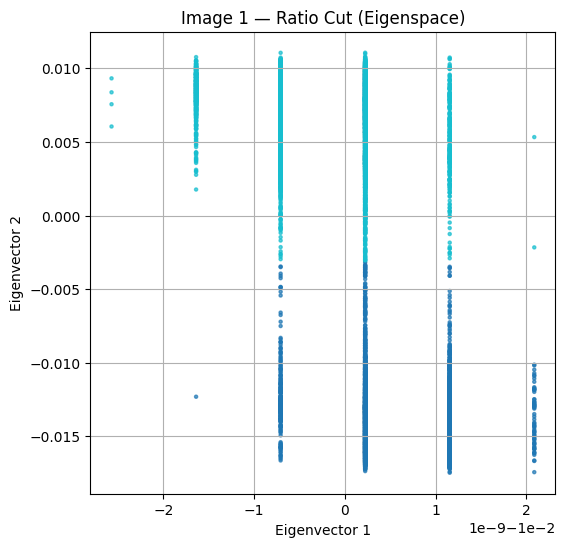

In [42]:
plot_eigenspace_part4(
    U1_ratio_kpp, labels1_ratio_kpp,
    title="Image 1 — Ratio Cut (Eigenspace)",
    save_path="img1_ratio_eigenspace.png"
)

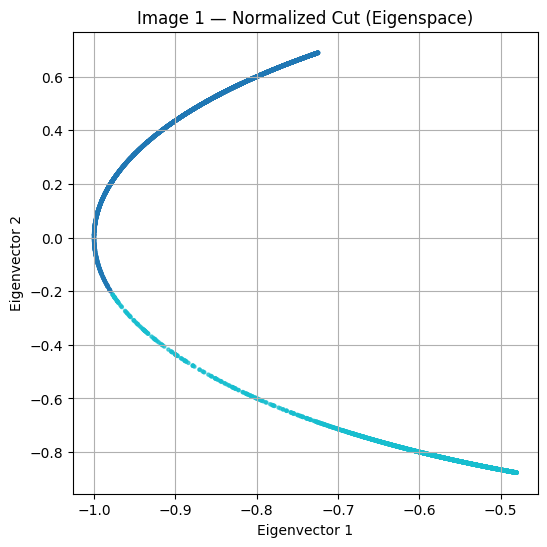

In [43]:
plot_eigenspace_part4(
    U1_ncut_kpp, labels1_ncut_kpp,
    title="Image 1 — Normalized Cut (Eigenspace)",
    save_path="img1_ncut_eigenspace.png"
)

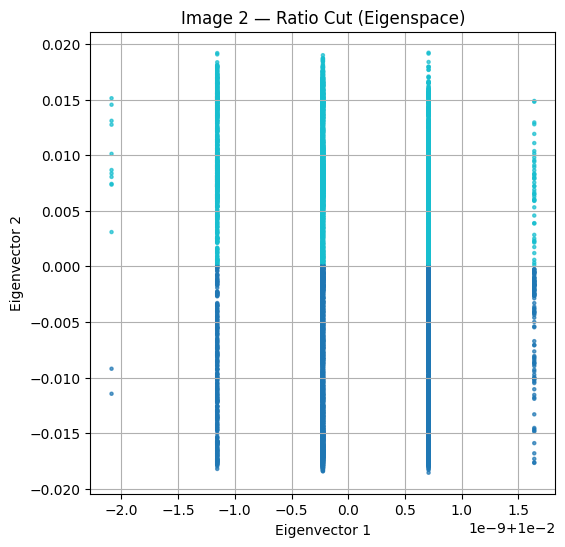

In [44]:
plot_eigenspace_part4(
    U2_ratio_kpp, labels2_ratio_kpp,
    title="Image 2 — Ratio Cut (Eigenspace)",
    save_path="img2_ratio_eigenspace.png"
)

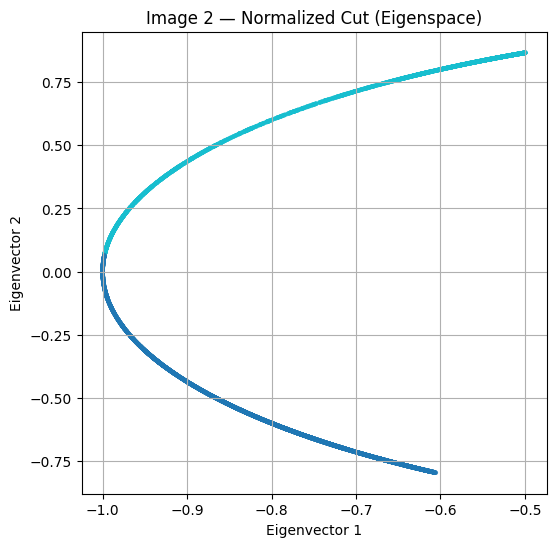

In [45]:
plot_eigenspace_part4(
    U2_ncut_kpp, labels2_ncut_kpp,
    title="Image 2 — Normalized Cut (Eigenspace)",
    save_path="img2_ncut_eigenspace.png"
)